# Image Captioning - Data And Training

This notebook covers:
1. Data loading and validation from `caption_data/`
2. Vocabulary/tokenization pipeline
3. Encoder-Decoder model definition (CNN + LSTM)
4. Training/validation loop
5. Saving model artifacts for inference notebook

In [1]:
# If needed, uncomment and run to install dependencies
# %pip install torch torchvision pandas pillow matplotlib tqdm scikit-learn

In [1]:
import json
import math
import os
import random
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

c:\Users\YZWUZ\OneDrive - Bayer\Desktop\deep\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
@dataclass
class CFG:
    data_root: str = 'caption_data'
    images_dir_name: str = 'images'
    captions_file_name: str = 'captions.txt'

    image_size: int = 128
    batch_size: int = 48
    num_workers: int = 0

    min_word_freq: int = 2
    max_caption_len: int = 30

    embed_dim: int = 256
    hidden_dim: int = 512
    num_layers: int = 1
    dropout: float = 0.3
    encoder_name: str = 'resnet18'

    lr: float = 1e-3
    weight_decay: float = 1e-5
    epochs: int = 6
    freeze_encoder: bool = True
    early_stopping_patience: int = 2
    min_improve: float = 1e-4

    captions_per_image_train: int = 1
    captions_per_image_eval: int = 1
    max_train_rows: int = 9000
    max_val_rows: int = 2000

    seed: int = 42
    artifacts_dir: str = 'artifacts'
    run_name: str = 'captioning_run'

cfg = CFG()

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

data_root = Path(cfg.data_root)
images_dir = data_root / cfg.images_dir_name
captions_path = data_root / cfg.captions_file_name

assert data_root.exists(), f'Missing folder: {data_root}'
assert images_dir.exists(), f'Missing images folder: {images_dir}'
assert captions_path.exists(), f'Missing captions file: {captions_path}'

Path(cfg.artifacts_dir).mkdir(parents=True, exist_ok=True)
run_dir = Path(cfg.artifacts_dir) / cfg.run_name
checkpoints_dir = run_dir / 'checkpoints'
plots_dir = run_dir / 'plots'
tables_dir = run_dir / 'tables'
samples_dir = run_dir / 'samples'
for p in [run_dir, checkpoints_dir, plots_dir, tables_dir, samples_dir]:
    p.mkdir(parents=True, exist_ok=True)
print('Artifacts root:', cfg.artifacts_dir)
print('Run directory:', run_dir)

Device: cpu
Artifacts root: artifacts
Run directory: artifacts\captioning_run


In [4]:
def parse_captions_file(captions_file: Path) -> pd.DataFrame:
    lines = captions_file.read_text(encoding='utf-8').splitlines()
    rows = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Skip common header patterns
        lowered = line.lower()
        if lowered.startswith('image,caption') or lowered.startswith('image	caption'):
            continue

        image_name = None
        caption = None

        if '\t' in line:
            parts = line.split('\t', 1)
            image_name, caption = parts[0].strip(), parts[1].strip()
        elif ',' in line:
            parts = line.split(',', 1)
            image_name, caption = parts[0].strip(), parts[1].strip()

        if image_name is None or caption is None:
            continue

        # Supports names like photo.jpg#0
        if '#' in image_name:
            image_name = image_name.split('#', 1)[0].strip()

        rows.append((image_name, caption))

    df = pd.DataFrame(rows, columns=['image_name', 'caption'])
    df = df.dropna().reset_index(drop=True)
    return df

captions_df = parse_captions_file(captions_path)
captions_df['image_path'] = captions_df['image_name'].apply(lambda n: str(images_dir / n))
captions_df = captions_df[captions_df['image_path'].map(lambda p: Path(p).exists())].reset_index(drop=True)
captions_df.to_csv(tables_dir / 'captions_parsed.csv', index=False)

print('Total rows:', len(captions_df))
print('Unique images:', captions_df['image_name'].nunique())
captions_df.head()

Total rows: 40455
Unique images: 8091


,image_name,caption,image_path
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,caption_data\images\1000268201_693b08cb0e.jpg
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,caption_data\images\1000268201_693b08cb0e.jpg
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,caption_data\images\1000268201_693b08cb0e.jpg
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,caption_data\images\1000268201_693b08cb0e.jpg
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,caption_data\images\1000268201_693b08cb0e.jpg


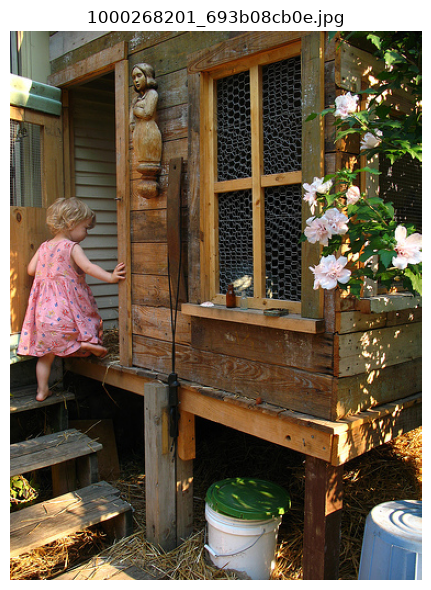

Captions:
- A child in a pink dress is climbing up a set of stairs in an entry way .
- A girl going into a wooden building .
- A little girl climbing into a wooden playhouse .
- A little girl climbing the stairs to her playhouse .
- A little girl in a pink dress going into a wooden cabin .


In [5]:
sample_image = captions_df['image_name'].iloc[0]
sample_rows = captions_df[captions_df['image_name'] == sample_image]
img = Image.open(images_dir / sample_image).convert('RGB')

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(sample_image)
plt.tight_layout()
plt.savefig(samples_dir / 'sample_image_and_captions.png', dpi=180)
plt.show()

print('Captions:')
for c in sample_rows['caption'].tolist():
    print('-', c)

In [6]:
def tokenize(text: str):
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.split()

special_tokens = ['<pad>', '<bos>', '<eos>', '<unk>']
token_counter = Counter()
for cap in captions_df['caption'].tolist():
    token_counter.update(tokenize(cap))

vocab_words = [w for w, c in token_counter.items() if c >= cfg.min_word_freq]
itos = special_tokens + sorted(vocab_words)
stoi = {w: i for i, w in enumerate(itos)}

pad_id = stoi['<pad>']
bos_id = stoi['<bos>']
eos_id = stoi['<eos>']
unk_id = stoi['<unk>']

print('Vocab size:', len(itos))

def encode_caption(text: str, max_len: int):
    toks = tokenize(text)[: max_len - 2]
    ids = [bos_id] + [stoi.get(t, unk_id) for t in toks] + [eos_id]
    return ids

def decode_ids(ids):
    words = []
    for i in ids:
        w = itos[i]
        if w in ('<bos>', '<pad>'):
            continue
        if w == '<eos>':
            break
        words.append(w)
    return ' '.join(words)

Vocab size: 5156


In [7]:
all_images = captions_df['image_name'].drop_duplicates().tolist()
train_imgs, temp_imgs = train_test_split(all_images, test_size=0.2, random_state=cfg.seed)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=cfg.seed)

train_df = captions_df[captions_df['image_name'].isin(train_imgs)].reset_index(drop=True)
val_df = captions_df[captions_df['image_name'].isin(val_imgs)].reset_index(drop=True)
test_df = captions_df[captions_df['image_name'].isin(test_imgs)].reset_index(drop=True)

train_df = train_df.groupby('image_name').head(cfg.captions_per_image_train).reset_index(drop=True)
val_df = val_df.groupby('image_name').head(cfg.captions_per_image_eval).reset_index(drop=True)
test_df = test_df.groupby('image_name').head(cfg.captions_per_image_eval).reset_index(drop=True)

if cfg.max_train_rows > 0 and len(train_df) > cfg.max_train_rows:
    train_df = train_df.sample(n=cfg.max_train_rows, random_state=cfg.seed).reset_index(drop=True)
if cfg.max_val_rows > 0 and len(val_df) > cfg.max_val_rows:
    val_df = val_df.sample(n=cfg.max_val_rows, random_state=cfg.seed).reset_index(drop=True)

print('Train rows:', len(train_df), '| images:', train_df['image_name'].nunique())
print('Val rows:', len(val_df), '| images:', val_df['image_name'].nunique())
print('Test rows:', len(test_df), '| images:', test_df['image_name'].nunique())

split_path = Path(cfg.artifacts_dir) / 'data_split.json'
split_payload = {'train_images': train_imgs, 'val_images': val_imgs, 'test_images': test_imgs}
split_path.write_text(json.dumps(split_payload, indent=2), encoding='utf-8')
(run_dir / 'data_split.json').write_text(json.dumps(split_payload, indent=2), encoding='utf-8')
train_df.to_csv(tables_dir / 'train_rows.csv', index=False)
val_df.to_csv(tables_dir / 'val_rows.csv', index=False)
test_df.to_csv(tables_dir / 'test_rows.csv', index=False)

Train rows: 32360 | images: 6472
Val rows: 4045 | images: 809
Test rows: 4050 | images: 810


In [8]:
train_tfms = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class CaptionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        image = self.transform(image)

        token_ids = encode_caption(row['caption'], cfg.max_caption_len)
        input_ids = torch.tensor(token_ids[:-1], dtype=torch.long)
        target_ids = torch.tensor(token_ids[1:], dtype=torch.long)

        return image, input_ids, target_ids

def collate_fn(batch):
    images, input_ids, target_ids = zip(*batch)
    images = torch.stack(images, dim=0)

    max_len = max(x.size(0) for x in input_ids)
    input_pad = torch.full((len(batch), max_len), pad_id, dtype=torch.long)
    target_pad = torch.full((len(batch), max_len), pad_id, dtype=torch.long)

    for i, (inp, tgt) in enumerate(zip(input_ids, target_ids)):
        input_pad[i, : inp.size(0)] = inp
        target_pad[i, : tgt.size(0)] = tgt

    return images, input_pad, target_pad

train_loader = DataLoader(CaptionDataset(train_df, train_tfms), batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, collate_fn=collate_fn)
val_loader = DataLoader(CaptionDataset(val_df, eval_tfms), batch_size=cfg.batch_size, shuffle=False,
                        num_workers=cfg.num_workers, collate_fn=collate_fn)

print('Train batches:', len(train_loader), 'Val batches:', len(val_loader))

Train batches: 1012 Val batches: 127


In [9]:
class EncoderCNN(nn.Module):
    def __init__(self, out_dim: int, freeze: bool = True, encoder_name: str = 'resnet18'):
        super().__init__()
        if encoder_name == 'resnet18':
            weights = models.ResNet18_Weights.DEFAULT
            backbone = models.resnet18(weights=weights)
        elif encoder_name == 'resnet34':
            weights = models.ResNet34_Weights.DEFAULT
            backbone = models.resnet34(weights=weights)
        else:
            weights = models.ResNet50_Weights.DEFAULT
            backbone = models.resnet50(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(in_features, out_dim)
        self.bn = nn.BatchNorm1d(out_dim)

        if freeze:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, images):
        feats = self.backbone(images)
        feats = self.proj(feats)
        feats = self.bn(feats)
        return feats

class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.img2h = nn.Linear(embed_dim, hidden_dim)
        self.img2c = nn.Linear(embed_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, image_embeds, input_ids):
        x = self.embedding(input_ids)
        x = self.dropout(x)

        h0 = torch.tanh(self.img2h(image_embeds)).unsqueeze(0)
        c0 = torch.tanh(self.img2c(image_embeds)).unsqueeze(0)

        outputs, _ = self.lstm(x, (h0, c0))
        logits = self.fc(outputs)
        return logits

class ImageCaptionModel(nn.Module):
    def __init__(self, vocab_size, cfg):
        super().__init__()
        self.encoder = EncoderCNN(cfg.embed_dim, freeze=cfg.freeze_encoder, encoder_name=cfg.encoder_name)
        self.decoder = DecoderLSTM(vocab_size, cfg.embed_dim, cfg.hidden_dim, cfg.num_layers, cfg.dropout)

    def forward(self, images, input_ids):
        image_embeds = self.encoder(images)
        logits = self.decoder(image_embeds, input_ids)
        return logits

model = ImageCaptionModel(len(itos), cfg).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

print(model.__class__.__name__, 'initialized')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\YZWUZ/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s] 


ImageCaptionModel initialized


In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for images, input_ids, target_ids in tqdm(loader, leave=False):
        images = images.to(device)
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits = model(images, input_ids)
        loss = criterion(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(1, len(loader))

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    for images, input_ids, target_ids in tqdm(loader, leave=False):
        images = images.to(device)
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits = model(images, input_ids)
        loss = criterion(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1))
        total_loss += loss.item()

    return total_loss / max(1, len(loader))

In [11]:
history = []
best_val = math.inf
best_ckpt_path = Path(cfg.artifacts_dir) / 'best_model.pt'
best_ckpt_run_path = checkpoints_dir / 'best_model.pt'

for epoch in range(1, cfg.epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = eval_one_epoch(model, val_loader, criterion)

    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    print(f'Epoch {epoch:02d}/{cfg.epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), best_ckpt_path)
        torch.save(model.state_dict(), best_ckpt_run_path)

    epoch_ckpt_path = checkpoints_dir / f'epoch_{epoch:02d}.pt'
    torch.save(model.state_dict(), epoch_ckpt_path)

history_df = pd.DataFrame(history)
history_df.to_csv(Path(cfg.artifacts_dir) / 'history.csv', index=False)
history_df.to_csv(tables_dir / 'history.csv', index=False)
(run_dir / 'history.json').write_text(history_df.to_json(orient='records', indent=2), encoding='utf-8')
history_df.tail()

Epoch 01/12 | train_loss=3.6412 | val_loss=3.1441


Epoch 02/12 | train_loss=2.8688 | val_loss=2.9594


Epoch 03/12 | train_loss=2.5789 | val_loss=2.9008


Epoch 04/12 | train_loss=2.3765 | val_loss=2.8949


Epoch 05/12 | train_loss=2.2171 | val_loss=2.9088


Epoch 06/12 | train_loss=2.0879 | val_loss=2.9510


Epoch 07/12 | train_loss=1.9768 | val_loss=2.9748


Epoch 08/12 | train_loss=1.8885 | val_loss=3.0194


KeyboardInterrupt: 

In [13]:
history_df = pd.DataFrame(history)
history_df.to_csv(Path(cfg.artifacts_dir) / 'history.csv', index=False)
history_df.to_csv(tables_dir / 'history.csv', index=False)
(run_dir / 'history.json').write_text(
    history_df.to_json(orient='records', indent=2),
    encoding='utf-8'
)

666

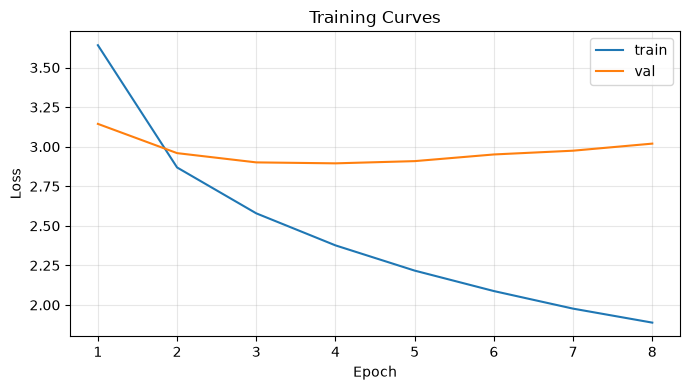

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train')
plt.plot(history_df['epoch'], history_df['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'training_curves.png', dpi=180)
plt.show()

In [15]:
vocab_path = Path(cfg.artifacts_dir) / 'vocab.json'
config_path = Path(cfg.artifacts_dir) / 'train_config.json'

vocab_payload = {
    'itos': itos,
    'stoi': stoi,
    'special_tokens': {'pad_id': pad_id, 'bos_id': bos_id, 'eos_id': eos_id, 'unk_id': unk_id},
}
vocab_path.write_text(json.dumps(vocab_payload, indent=2), encoding='utf-8')

cfg_payload = cfg.__dict__.copy()
cfg_payload['vocab_size'] = len(itos)
config_path.write_text(json.dumps(cfg_payload, indent=2), encoding='utf-8')
(run_dir / 'vocab.json').write_text(json.dumps(vocab_payload, indent=2), encoding='utf-8')
(run_dir / 'train_config.json').write_text(json.dumps(cfg_payload, indent=2), encoding='utf-8')

final_ckpt_path = checkpoints_dir / 'last_model.pt'
torch.save(model.state_dict(), final_ckpt_path)

run_summary = {
    'best_val_loss': float(best_val),
    'epochs_completed': int(len(history_df)),
    'vocab_size': int(len(itos)),
    'num_train_rows': int(len(train_df)),
    'num_val_rows': int(len(val_df)),
    'num_test_rows': int(len(test_df)),
    'device': str(device)
}
(run_dir / 'run_summary.json').write_text(json.dumps(run_summary, indent=2), encoding='utf-8')

print('Saved artifacts:')
print('-', best_ckpt_path)
print('-', best_ckpt_run_path)
print('-', final_ckpt_path)
print('-', vocab_path)
print('-', config_path)
print('-', Path(cfg.artifacts_dir) / 'history.csv')
print('-', Path(cfg.artifacts_dir) / 'data_split.json')
print('-', run_dir / 'run_summary.json')
print('-', plots_dir / 'training_curves.png')

Saved artifacts:
- artifacts\best_model.pt
- artifacts\captioning_run\checkpoints\best_model.pt
- artifacts\captioning_run\checkpoints\last_model.pt
- artifacts\vocab.json
- artifacts\train_config.json
- artifacts\history.csv
- artifacts\data_split.json
- artifacts\captioning_run\run_summary.json
- artifacts\captioning_run\plots\training_curves.png


## Next Step

After training finishes, open `inference.ipynb` to load the saved artifacts and test on unseen images.